<a href="https://colab.research.google.com/github/charlottejocelynne/indobert-vs-mbert-for-indonesian-hoax-news-detection/blob/main/Data%20Preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Dataset

In [ ]:
import pandas as pd
import numpy as np
import io

df1 = pd.read_excel('/content/dataset_cnn_summarized.xlsx')
df2 = pd.read_excel('/content/dataset_kompas_summarized.xlsx')
df3 = pd.read_excel('/content/dataset_tempo_summarized.xlsx')
df4 = pd.read_excel('/content/dataset_turnbackhoax_summarized.xlsx')

In [ ]:
df1_selected = df1[['title','summarized','label']]
df2_selected = df2[['title','summarized','label']]
df3_selected = df3[['title','summarized','label']]

In [ ]:
df1_selected

,title,summarized,label
0,Anies di Milad BKMT: Pengajian Menghasilkan Ib...,Mantan Gubernur DKI Jakarta Anies Baswedan men...,0
1,Edy Soal Pilgub Sumut: Kalau yang Maju Abal-ab...,Gubernur Sumatera Utara Edy Rahmayadi membuka ...,0
2,PKB Bakal Daftarkan Menaker Ida Fauziyah Jadi ...,PKB bakal mengusung Menteri Ketenagakerjaan Id...,0
3,Gede Pasek Doakan AHY Jadi Capres atau Cawapres,Ketua Umum Partai Kebangkitan Nusantara (PKN) ...,0
4,PKN Siapkan Jabatan Khusus Buat Anas Urbaningr...,Dewan Pimpinan Pusat PKN menyiapkan jabatan kh...,0
...,...,...,...
9625,Aroma Politik di Balik Penetapan 1 Juni Hari L...,Penetapan 1 Juni Hari Lahir Pancasila dan hari...,0
9626,Jokowi Wanti-wanti Ekspansi Ideologi Transnasi...,Presiden Joko Widodo mengungkapkan pesatnya pe...,0
9627,PBNU: Tak ada Pertentangan antara Islam dan Pa...,"Di momen Hari Lahir Pancasila, Sekretaris Jend...",0
9628,Jokowi Bicara Ideologi Transnasional di Revolu...,Presiden Joko Widodo (Jokowi) mengungkapkan se...,0


In [ ]:
df2_selected

,title,summarized,label
0,"Efek Ekor Jas Pencalonan Anies, Elektabilitas ...",Hasil jajak pendapat yang diselenggarakan Litb...,0
1,"Ekonomi 2024 Ditargetkan Tumbuh 5,7 Persen, pa...",Pemerintah menargetkan pertumbuhan ekonomi di ...,0
2,"Survei Litbang Kompas: PDI-P, Gerindra, dan Go...","PDI-P, Gerindra, dan Golkar menempati posisi t...",0
3,"Survei Litbang ""Kompas"": Popularitas Golkar Te...","Popularitas Golkar Tertinggi, Diikuti PDI-P, d...",0
4,"""Endorsement"" dan Basa-basi Politik ala Jokowi...",Basis massa pendukung Jokowi diprediksi tak ak...,0
...,...,...,...
4724,Nurul Arifin Ajak Perempuan Terjun ke Dunia Po...,Ketua DPP Partai Golkar Nurul Arifin mendorong...,0
4725,Kebangkitan Lawan Politik Jokowi...,Pasangan Anies Baswedan-Sandiaga Uno memenangi...,0
4726,Ridwan Kamil Akui Pilkada DKI Berdampak pada S...,"Ridwan Kamil menilai, hasil Pilkada DKI Jakart...",0
4727,Anies Belum Berpikir Apakah Akan Menjadi Anggo...,Calon gubernur DKI Jakarta Anies Baswedan masi...,0


In [ ]:
df3_selected

,title,summarized,label
0,Ma'ruf Amin akan Saksikan Lagi Timnas Indonesi...,Timnas Indonesia Vs Thailand akan Tampil Lagi ...,0
1,Menag Yaqut Canangkan 2022 Sebagai Tahun Toler...,Pemerintah mencanangkan 2022 sebagai Tahun Tol...,0
2,Jokowi Ajak Masyarakat Hadapi 2022 dengan Sema...,"@jokowi.net, melaporkan bahwa dia mengajak mas...",0
3,"Top Nasional: Strategi Hadapi Omicron, Lemhana...",Pemerintah Lemhanas Usul Bentuk Kementerian Ba...,0
4,"Mulai Tahun Ini, Menteri Tjahjo Kumolo Minta P...",Menteri Tjahjo Kumolo Minta PNS Apel Pagi Tiap...,0
...,...,...,...
6587,5 Fakta dan Kasak-kusuk Jabatan Gubernur Diusu...,"Gubernur Ridwan Kamil di Medan, Selasa 31 Janu...",0
6588,Komentari soal PDIP Enggan Berkoalisi dengan P...,Hasto mengaku partainya tak khawatir ketinggal...,0
6589,Top Nasional: NasDem Bilang Piagam Deklarasi K...,Ketua Umum Partai NasDem Surya Paloh kembali b...,0
6590,NasDem Sebut Demokrat Tak Ngotot Sodorkan AHY ...,Pimpinan parpol Koalisi Perubahan bakal bertem...,0


In [ ]:
df4

,index,title,raw timestamp,original,tags,author,url,politik,raw narasi,cleaned,label,timestamp,cleaned token length,summarized
0,0,[SALAH] Anies Baswedan Dekat Dengan Aliran Krs...,"Maret 1, 2023",Hasil Periksa Fakta Gabriela Nauli Sinaga (Uni...,Fitnah;Hasut;Hoax,Pemeriksa Fakta Junior,https://turnbackhoax.id/2023/03/01/salah-anies...,1,\n“BISA DILIHAT SI ONTA YAMAN NGGAK PEDULI ITU...,BISA DILIHAT SI ONTA YAMAN NGGAK PEDULI ITU AP...,1,2023-03-01,43,ONTA YAMAN NGGAK PEDULI ITU APA YANG PENTING D...
1,1,[SALAH] Hakim Wahyu Iman Santoso Alami Kecelak...,"Maret 1, 2023",Hasil Periksa Fakta Gabriela Nauli Sinaga (Uni...,Fitnah;Hasut;Hoax,Pemeriksa Fakta Junior,https://turnbackhoax.id/2023/03/01/salah-hakim...,0,\n“ini bener gasih?? Ya Allah gimna keadaan pa...,ini bener gasih?? Ya Allah gimna keadaan pa ha...,1,2023-03-01,36,Ya Allah gimna keadaan pa hakim? Ini bener gas...
2,2,[SALAH] GAMBAR MEGAWATI DAN PUAN BERMAIN SLOT,"Februari 28, 2023",Hasil Periksa Fakta Gabriela Nauli Sinaga (Uni...,Fitnah;Hasut;Hoax,Pemeriksa Fakta Junior,https://turnbackhoax.id/2023/02/28/salah-gamba...,1,\n“Nenek lampir pemimpin partai banteng bercul...,Nenek lampir pemimpin partai banteng bercula s...,1,2023-02-28,71,Nenek lampir pemimpin partai banteng bercula s...
3,3,[SALAH] JONATHAN LATUMAHINA SEORANG NASRANI DA...,"Februari 28, 2023",Hasil Periksa Fakta Gabriela Nauli Sinaga (Uni...,Fitnah;Hasut;Hoax,Pemeriksa Fakta Junior,https://turnbackhoax.id/2023/02/28/salah-jonat...,0,\n“gerombolan kulup banyak menyusup ke ormas2 ...,gerombolan kulup banyak menyusup ke ormas2 isl...,1,2023-02-28,81,kulup banyak menyusup ke ormas2 islam. hati2 d...
4,4,[SALAH] PESAN WHATSAPP DARI BMKG YANG KABARKAN...,"Februari 28, 2023",Hasil Periksa Fakta Gabriela Nauli Sinaga (Uni...,Fitnah;Hasut;Hoax,Pemeriksa Fakta Junior,https://turnbackhoax.id/2023/02/28/salah-pesan...,1,,NaN,1,2023-02-28,3,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10376,10379,(HOAX) Foto Raja Salman Mengangkat Tandu Jenaz...,2015-09-15 00:00:00,Sumber : media sosial\nNarasi : Raja Salman da...,Fitnah;Hasut;Hoax,Bentang Febrylian,https://turnbackhoax.id/2015/09/15/hoax-foto-r...,0,Raja Salman dari arab saudi membawa orang-ora...,Raja Salman dari arab saudi membawa orang-oran...,1,2015-09-15,36,Raja Salman dari arab saudi membawa orang-oran...
10377,10380,"(HOAX) Jokowi dituduh bodoh, salah cara dalam ...",2015-09-12 00:00:00,"Sumber : media sosial\nNarasi : hehe, selalu b...",Fitnah;Hasut;Hoax,Bentang Febrylian,https://turnbackhoax.id/2015/09/12/jokowi-ditu...,1,"hehe, selalu bisa tersenyum melihat tingkah l...","hehe, selalu bisa tersenyum melihat tingkah la...",1,2015-09-12,32,Jokowi selalu bisa tersenyum melihat tingkah l...
10378,10381,(FITNAH) Jokowi dituduh memasukkan ribuan tena...,2015-09-08 00:00:00,Sumber : Media Sosial\nNarasi : Pak Jokowi itu...,Fitnah;Hasut;Hoax,Bentang Febrylian,https://turnbackhoax.id/2015/09/08/jokowi-ditu...,1,Pak Jokowi itu menjadi walikota periode perta...,Pak Jokowi itu menjadi walikota periode pertam...,1,2015-09-08,143,Jokowi bersalah karena lebih mementingkan chin...
10379,10382,(HOAX) Mata Uang Rupiah Terpuruk,2015-09-08 00:00:00,"Sumber : media sosial\nNarasi : Hari ini, Rabu...",Fitnah;Hasut;Hoax,Bentang Febrylian,https://turnbackhoax.id/2015/09/08/mata-uang-r...,0,"Hari ini, Rabu (23/09/2015), nilai tukar rupi...","Hari ini, Rabu (23/09/2015), nilai tukar rupia...",1,2015-09-08,31,Nilai tukar rupiah terpuruk hingga sempat mele...


In [ ]:
#Data df4 masih menampilkan data yang memiliki berita yang bukan politik, sehingga dataset tersebut harus di filter untuk mendapatkan hanya berita yang politik saja
df4_filtered = df4[df4['politik'] == 1]
df4_selected = df4_filtered[['title','summarized','label']]

# Menghapus kata di awal berita hoaks tidak relevan

In [ ]:
import pandas as pd
from collections import Counter

# Memuat dataset
# Misalnya nama dataset Anda adalah df
# df = pd.read_csv('path/to/your/dataset.csv')  # sesuaikan path ke dataset Anda

# Mengambil kata pertama dari setiap judul
first_words = df4_selected['title'].str.split().str[0]

# Menghitung kemunculan setiap kata pertama
first_word_counts = Counter(first_words)

# Menampilkan hasil
print("Kata-kata pertama yang ada di depan title beserta jumlah kemunculannya:")
for word, count in first_word_counts.most_common():
    print(f"{word}: {count}")


Kata-kata pertama yang ada di depan title beserta jumlah kemunculannya:
[SALAH]: 1628
[BENAR]: 197
[HOAX]: 77
[KLARIFIKASI]: 70
[DISINFORMASI]: 59
[BERITA]: 41
HOAX:: 27
(HOAX): 23
[SALAH]:: 15
(KLARIFIKASI): 8
(HOAX):: 8
(DISINFORMASI): 7
(FITNAH): 7
(SALAH):: 6
[FITNAH]: 6
(DISINFORMASI):: 5
[FALSE]: 4
[MISINFORMASI]: 4
(EDUKASI): 4
[ISU]: 4
HASUT:: 4
(DISINFORMASI+FITNAH): 3
(BENAR): 2
[HOAX: 2
[EDUKASI]: 2
FITNAH:: 2
(FITNAH):: 2
FITNAH: 2
SALAH]: 1
[UPDATE]: 1
[ACARA]: 1
Facebook:: 1
[Cek: 1
[CekFakta]: 1
[BENAR]:: 1
[Isu]: 1
(DISINFORMASI: 1
(SALAH): 1
[SALAH: 1
(BENAR):: 1
[Benar]: 1
[DISINFORMASI+HASUT]: 1
[HOAX/FITNAH]: 1
[HASUT+FITNAH]: 1
(HASUT):: 1
[INFORMASI]: 1
(EDUKASI):: 1
(MISINFORMASI):: 1
(HOAX/HASUT):: 1
(FITNAH+HASUT): 1
(KLARIFIKASI):: 1
(BERITA): 1
(MISINFORMASI): 1
[BERITA,: 1
(FITNAH: 1
(Campuran;: 1
(HOAX)Permen: 1
(HASUT): 1
(HOAX+FITNAH): 1
HOAX: 1


In [ ]:
# Daftar kata-kata pembuka yang ingin dihapus
irrelevant_words = [
    "[SALAH]", "[BENAR]", "[HOAX]", "[KLARIFIKASI]", "[DISINFORMASI]", "[BERITA]", "HOAX:", "(HOAX)", "[FALSE]",
    "(FITNAH)", "[FITNAH]", "[MISINFORMASI]", "(EDUKASI)", "[ISU]", "HASUT:", "(DISINFORMASI+FITNAH)", "(BENAR)",
    "[UPDATE]", "[ACARA]", "[Cek Fakta]", "[CekFakta]", "[Isu]", "(DISINFORMASI", "(HOAX/HASUT)", "(HOAX+FITNAH)",
    "(HASUT)", "(EDUKASI)", "(MISINFORMASI)", "(FITNAH+HASUT)", "(KLARIFIKASI)", "(BERITA)", "[BERITA,"
]

# Membuat pola regex untuk mencocokkan kata-kata yang akan dihapus di awal title
import re
pattern = re.compile(r'^(' + '|'.join(map(re.escape, irrelevant_words)) + r')\s*')

# Menghapus kata-kata yang cocok di awal judul
df4_selected['title'] = df4_selected['title'].str.replace(pattern, '', regex=True)

# Menampilkan hasil
df4_selected['title']


<ipython-input-9-5153f9e0edd1>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4_selected['title'] = df4_selected['title'].str.replace(pattern, '', regex=True)


,title
0,Anies Baswedan Dekat Dengan Aliran Krsiten Ses...
2,GAMBAR MEGAWATI DAN PUAN BERMAIN SLOT
4,PESAN WHATSAPP DARI BMKG YANG KABARKAN GUNUNG ...
5,"PDI-P Diblacklist dari Peserta Pilpres, Tak Bi..."
13,ANIES AKUI SUAP FIRLI BAHURI AGAR NAMANYA BERSIH
...,...
10374,"Dituduh PKI Bangkit di Pamekasan, Jokowi Dicac..."
10375,Larangan anti-miras di Minimarket ditiadakan o...
10377,"Jokowi dituduh bodoh, salah cara dalam bersala..."
10378,Jokowi dituduh memasukkan ribuan tenaga kerja ...


In [ ]:
df4_selected

,title,summarized,label
0,Anies Baswedan Dekat Dengan Aliran Krsiten Ses...,ONTA YAMAN NGGAK PEDULI ITU APA YANG PENTING D...,1
2,GAMBAR MEGAWATI DAN PUAN BERMAIN SLOT,Nenek lampir pemimpin partai banteng bercula s...,1
4,PESAN WHATSAPP DARI BMKG YANG KABARKAN GUNUNG ...,NaN,1
5,"PDI-P Diblacklist dari Peserta Pilpres, Tak Bi...",Beredar sebuah unggahan di Facebook dengan nar...,1
13,ANIES AKUI SUAP FIRLI BAHURI AGAR NAMANYA BERSIH,"AKU1 SEMUAnya, AN1ES'I SU4P FIRLI BAHURI AG4R ...",1
...,...,...,...
10374,"Dituduh PKI Bangkit di Pamekasan, Jokowi Dicac...",KAMPANYE ada warning dugaan PKI bangkit di Era...,1
10375,Larangan anti-miras di Minimarket ditiadakan o...,Presiden Joko Widodo telah mengumumkan paket k...,1
10377,"Jokowi dituduh bodoh, salah cara dalam bersala...",Jokowi selalu bisa tersenyum melihat tingkah l...,1
10378,Jokowi dituduh memasukkan ribuan tenaga kerja ...,Jokowi bersalah karena lebih mementingkan chin...,1


# Menggabungkan ke-4 dataset

In [ ]:
df = pd.concat([df1_selected, df2_selected, df3_selected, df4_selected], ignore_index=True)

In [ ]:
df['text'] = df['title'] + ". " + df['summarized']

# Tampilkan hasil
df_selected = df[['text','label']]

In [ ]:
df_selected['text'] = df_selected['text'].astype(str)

<ipython-input-13-f9f7050b24cf>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['text'] = df_selected['text'].astype(str)


In [ ]:
df_selected

,text,label
0,Anies di Milad BKMT: Pengajian Menghasilkan Ib...,0
1,Edy Soal Pilgub Sumut: Kalau yang Maju Abal-ab...,0
2,PKB Bakal Daftarkan Menaker Ida Fauziyah Jadi ...,0
3,Gede Pasek Doakan AHY Jadi Capres atau Cawapre...,0
4,PKN Siapkan Jabatan Khusus Buat Anas Urbaningr...,0
...,...,...
23197,"Dituduh PKI Bangkit di Pamekasan, Jokowi Dicac...",1
23198,Larangan anti-miras di Minimarket ditiadakan o...,1
23199,"Jokowi dituduh bodoh, salah cara dalam bersala...",1
23200,Jokowi dituduh memasukkan ribuan tenaga kerja ...,1


In [ ]:
jumlah_label_0 = df['label'].value_counts()[0]
jumlah_label_1 = df['label'].value_counts()[1]

print(f"Jumlah label 0: {jumlah_label_0}")
print(f"Jumlah label 1: {jumlah_label_1}")

Jumlah label 0: 20951
Jumlah label 1: 2251


# Cleaning Data

In [ ]:
import re

def clean_text(text):
    # Lowercasing
    text = text.lower()

    # Menghapus URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Menghapus angka
    text = re.sub(r'\d+', '', text)

    # Menghapus karakter yang tidak perlu dan hanya menyisakan alfabet dan spasi
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Menghapus spasi ganda
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
jumlah_label_0 = df['label'].value_counts()[0]
jumlah_label_1 = df['label'].value_counts()[1]

print(f"Jumlah label 0: {jumlah_label_0}")
print(f"Jumlah label 1: {jumlah_label_1}")

Jumlah label 0: 20951
Jumlah label 1: 2251


In [ ]:
# Menghapus baris yang mengandung kata "nan" di kolom 'text'
df_selected = df_selected[~df_selected['text'].str.contains(r'\bnan\b', case=False)]

In [ ]:
# Menghitung jumlah kemunculan "nan" di kolom 'text'
nan_strings = df_selected['text'].str.contains(r'\bnan\b', case=False).sum()
print("Jumlah kata 'nan' dalam kolom 'text':", nan_strings)

Jumlah kata 'nan' dalam kolom 'text': 0


In [ ]:
# Mencari baris yang hanya mengandung kata 'nan' secara persis
nan_rows = df_selected[df_selected['text'].str.strip().str.lower() == 'nan']

# Menampilkan jumlah baris yang hanya berisi kata 'nan'
print(f"Jumlah baris yang hanya mengandung kata 'nan': {len(nan_rows)}")

# Menampilkan teks yang hanya mengandung kata 'nan'
print("Teks yang hanya mengandung 'nan':")
print(nan_rows)

# Jika ingin menyimpan teks tersebut ke dalam file CSV
nan_rows.to_csv("texts_with_exact_nan.csv", index=False)
print("Teks yang hanya mengandung 'nan' telah disimpan ke texts_with_exact_nan.csv")


Jumlah baris yang hanya mengandung kata 'nan': 0
Teks yang hanya mengandung 'nan':
Empty DataFrame
Columns: [text, label]
Index: []
Teks yang hanya mengandung 'nan' telah disimpan ke texts_with_exact_nan.csv


In [ ]:
# Menghapus baris yang ada di nan_rows dari df_selected
df_selected.drop(nan_rows.index, inplace=True)

# Menampilkan hasil setelah penghapusan
print(f"Jumlah baris setelah penghapusan: {len(df_selected)}")

Jumlah baris setelah penghapusan: 22062


In [ ]:
# Contoh: Menghapus kata "klik" dari kolom 'text'
df_selected['text'] = df_selected['text'].str.replace(r'\bklik\b', '', regex=True)

In [ ]:
df_selected['text'] = df_selected['text'].apply(clean_text)

In [ ]:
import pandas as pd

# Membuat DataFrame contoh (jika belum ada df_selected)
df_sample = df_selected[['text']].copy()
df_sample['cleaned_text'] = df_sample['text'].apply(clean_text)

# Menampilkan beberapa sampel data sebelum dan sesudah pembersihan
print(df_sample.head(10))  # Menampilkan 10 sampel pertama


                                                text  \
0  Anies di Milad BKMT: Pengajian Menghasilkan Ib...   
1  Edy Soal Pilgub Sumut: Kalau yang Maju Abal-ab...   
2  PKB Bakal Daftarkan Menaker Ida Fauziyah Jadi ...   
3  Gede Pasek Doakan AHY Jadi Capres atau Cawapre...   
4  PKN Siapkan Jabatan Khusus Buat Anas Urbaningr...   
5  Nurdin: Kalaupun Bukan Menpora, Jatah Golkar d...   
6  HNW Sebut PKS Deklarasi Anies Capres Secara Re...   
7  Jazilul PKB Sindir PPP: Jangan Kayak Partai Ij...   
8  Eks Politikus PDIP Laksamana Sukardi Gabung PK...   
9  PKS Gelar Rakernas Akhir Pekan Ini, Anies Dija...   

                                        cleaned_text  
0  anies di milad bkmt pengajian menghasilkan ibu...  
1  edy soal pilgub sumut kalau yang maju abalabal...  
2  pkb bakal daftarkan menaker ida fauziyah jadi ...  
3  gede pasek doakan ahy jadi capres atau cawapre...  
4  pkn siapkan jabatan khusus buat anas urbaningr...  
5  nurdin kalaupun bukan menpora jatah golkar di ... 

In [ ]:
df_sample.to_csv(f"Tabel Perbedaan Pembersihan Data.csv", index=False)

In [ ]:
jumlah_label_0 = df_selected['label'].value_counts()[0]
jumlah_label_1 = df_selected['label'].value_counts()[1]

print(f"Jumlah label 0: {jumlah_label_0}")
print(f"Jumlah label 1: {jumlah_label_1}")

Jumlah label 0: 20760
Jumlah label 1: 1302


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


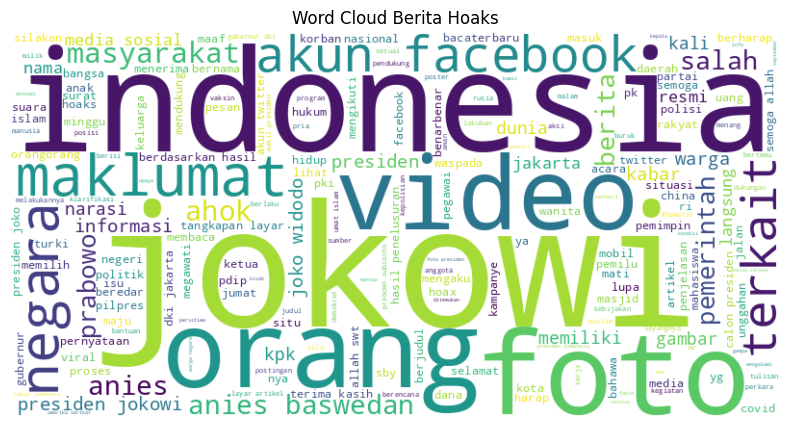

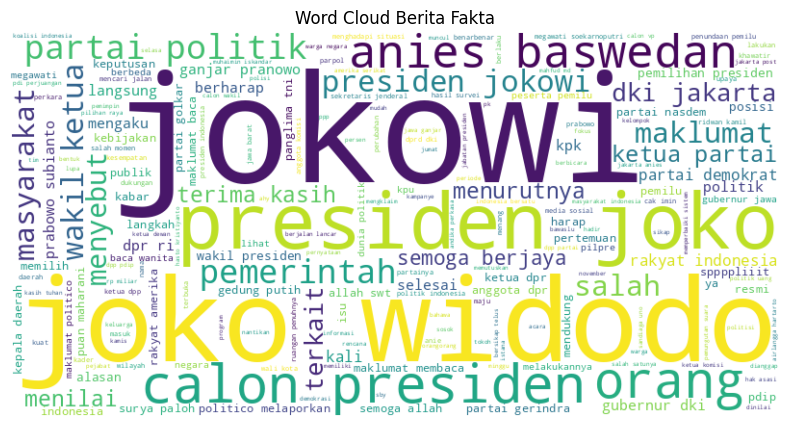

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Asumsikan 'df' adalah DataFrame dengan kolom 'cleaned' dan 'label'
# di mana 'label' berisi 0 (fakta) atau 1 (hoaks)

# Pisahkan data berita hoaks dan fakta
# Use integer values for filtering
data_hoaks = df_selected[df_selected['label'] == 1]['text']
data_fakta = df_selected[df_selected['label'] == 0]['text']

# Gabungkan teks berita hoaks menjadi satu string
teks_hoaks = ' '.join(data_hoaks)
teks_fakta = ' '.join(data_fakta)

# Definisikan stop words bahasa Indonesia
stop_words = set(stopwords.words('indonesian'))

# Buat fungsi untuk menghasilkan word cloud
def buat_wordcloud(cleaned, judul):
    word_tokens = word_tokenize(cleaned)
    filtered_text = [w for w in word_tokens if not w.lower() in stop_words]
    filtered_text = ' '.join(filtered_text)

    # --- HANDLE EMPTY TEXT ---
    if not filtered_text:  # Check if filtered_text is empty
        print(f"Tidak ada teks untuk membuat word cloud untuk '{judul}'.")
        return  # Exit the function if no text is available
    # --- END HANDLE EMPTY TEXT ---

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(filtered_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(judul)
    plt.show()

# Buat word cloud untuk data berita hoaks
buat_wordcloud(teks_hoaks, "Word Cloud Berita Hoaks")

# Buat word cloud untuk data berita fakta
buat_wordcloud(teks_fakta, "Word Cloud Berita Fakta")

# Balancing Data

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.utils import shuffle
import pandas as pd

In [ ]:
# Data awal
X = df_selected['text'].values.reshape(-1, 1)  # Data teks (diubah menjadi array 2D)
y = df_selected['label']                      # Data label

In [ ]:
# Fraksi data
train_frac = 0.7
valid_frac = 0.15
test_frac = 0.15

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.utils import shuffle
import pandas as pd

# Loop untuk 10 kali undersampling dan pembagian dataset
for i in range(1, 11):
    # Random undersampling
    undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=i)
    X_resampled, y_resampled = undersampler.fit_resample(X, y)

    # Gabungkan kembali data teks dan label
    resampled_data = pd.DataFrame({
        'text': X_resampled.flatten(),  # Kembalikan array 2D ke 1D
        'label': y_resampled
    })

    # Shuffle data
    resampled_data = shuffle(resampled_data, random_state=42).reset_index(drop=True)

    # Hitung distribusi label dataset keseluruhan
    label_counts = resampled_data['label'].value_counts()

    print(f"\nJumlah Dataset {i}: {len(resampled_data)}")
    print(f"Distribusi Label Dataset {i}:")
    print(f"0: {label_counts[0]}")
    print(f"1: {label_counts[1]}")

    # Split berdasarkan label
    df_label_0 = resampled_data[resampled_data['label'] == 0]
    df_label_1 = resampled_data[resampled_data['label'] == 1]

    # Hitung ukuran untuk setiap subset
    train_size_0 = int(train_frac * len(df_label_0))
    valid_size_0 = int(valid_frac * len(df_label_0))

    train_size_1 = int(train_frac * len(df_label_1))
    valid_size_1 = int(valid_frac * len(df_label_1))

    # Split data label 0
    train_0 = df_label_0[:train_size_0]
    valid_0 = df_label_0[train_size_0:train_size_0 + valid_size_0]
    test_0 = df_label_0[train_size_0 + valid_size_0:]

    # Split data label 1
    train_1 = df_label_1[:train_size_1]
    valid_1 = df_label_1[train_size_1:train_size_1 + valid_size_1]
    test_1 = df_label_1[train_size_1 + valid_size_1:]

    # Gabungkan data
    train_df = pd.concat([train_0, train_1]).sample(frac=1, random_state=42).reset_index(drop=True)
    valid_df = pd.concat([valid_0, valid_1]).sample(frac=1, random_state=42).reset_index(drop=True)
    test_df = pd.concat([test_0, test_1]).sample(frac=1, random_state=42).reset_index(drop=True)

    # Hitung distribusi label untuk setiap subset
    train_label_counts = train_df['label'].value_counts()
    valid_label_counts = valid_df['label'].value_counts()
    test_label_counts = test_df['label'].value_counts()

    print(f"\nJumlah data train pada dataset {i}: {len(train_df)}")
    print("Distribusi Label:")
    print(f"0: {train_label_counts[0]}")
    print(f"1: {train_label_counts[1]}")

    print(f"\nJumlah data validation pada dataset {i}: {len(valid_df)}")
    print("Distribusi Label:")
    print(f"0: {valid_label_counts[0]}")
    print(f"1: {valid_label_counts[1]}")

    print(f"\nJumlah data test pada dataset {i}: {len(test_df)}")
    print("Distribusi Label:")
    print(f"0: {test_label_counts[0]}")
    print(f"1: {test_label_counts[1]}")

    # Simpan hasil ke file CSV
    train_df.to_csv(f"undersampled_dataset_{i}_train.csv", index=False)
    valid_df.to_csv(f"undersampled_dataset_{i}_validation.csv", index=False)
    test_df.to_csv(f"undersampled_dataset_{i}_test.csv", index=False)

    print(f"\nDataset {i} disimpan: train, validation, dan test")



Jumlah Dataset 1: 2604
Distribusi Label Dataset 1:
0: 1302
1: 1302

Jumlah data train pada dataset 1: 1822
Distribusi Label:
0: 911
1: 911

Jumlah data validation pada dataset 1: 390
Distribusi Label:
0: 195
1: 195

Jumlah data test pada dataset 1: 392
Distribusi Label:
0: 196
1: 196

Dataset 1 disimpan: train, validation, dan test

Jumlah Dataset 2: 2604
Distribusi Label Dataset 2:
0: 1302
1: 1302

Jumlah data train pada dataset 2: 1822
Distribusi Label:
0: 911
1: 911

Jumlah data validation pada dataset 2: 390
Distribusi Label:
0: 195
1: 195

Jumlah data test pada dataset 2: 392
Distribusi Label:
0: 196
1: 196

Dataset 2 disimpan: train, validation, dan test

Jumlah Dataset 3: 2604
Distribusi Label Dataset 3:
0: 1302
1: 1302

Jumlah data train pada dataset 3: 1822
Distribusi Label:
0: 911
1: 911

Jumlah data validation pada dataset 3: 390
Distribusi Label:
0: 195
1: 195

Jumlah data test pada dataset 3: 392
Distribusi Label:
0: 196
1: 196

Dataset 3 disimpan: train, validation, dan 

In [ ]:
# Define function to display data info
def display_data_info(dataset_type, num_datasets=10):
    for i in range(1, num_datasets + 1):
        filename = f"undersampled_dataset_{i}_{dataset_type}.csv"
        dataset = pd.read_csv(filename)

        print(f"Dataset {i} ({dataset_type}):")
        print(f"Jumlah data: {len(dataset)}")
        print("Distribusi label:")
        print(dataset['label'].value_counts())
        print("\n")

# Display info for train, test, and validation datasets
display_data_info("train")
display_data_info("test")
display_data_info("validation")

Dataset 1 (train):
Jumlah data: 1822
Distribusi label:
label
0    911
1    911
Name: count, dtype: int64


Dataset 2 (train):
Jumlah data: 1822
Distribusi label:
label
0    911
1    911
Name: count, dtype: int64


Dataset 3 (train):
Jumlah data: 1822
Distribusi label:
label
0    911
1    911
Name: count, dtype: int64


Dataset 4 (train):
Jumlah data: 1822
Distribusi label:
label
0    911
1    911
Name: count, dtype: int64


Dataset 5 (train):
Jumlah data: 1822
Distribusi label:
label
0    911
1    911
Name: count, dtype: int64


Dataset 6 (train):
Jumlah data: 1822
Distribusi label:
label
0    911
1    911
Name: count, dtype: int64


Dataset 7 (train):
Jumlah data: 1822
Distribusi label:
label
0    911
1    911
Name: count, dtype: int64


Dataset 8 (train):
Jumlah data: 1822
Distribusi label:
label
0    911
1    911
Name: count, dtype: int64


Dataset 9 (train):
Jumlah data: 1822
Distribusi label:
label
0    911
1    911
Name: count, dtype: int64


Dataset 10 (train):
Jumlah data: 1822

In [ ]:
# Iterasi untuk setiap dataset TRAIN
for i in range(1, 11):  # Dari dataset 1 hingga dataset 10
    filename = f"undersampled_dataset_{i}_train.csv"  # Nama file CSV
    dataset = pd.read_csv(filename)  # Baca dataset

    # Tampilkan distribusi label
    print(f"Distribusi label di dataset {i}:")
    print(dataset['label'].value_counts())  # Hitung jumlah label 0 dan 1
    print("\n")  # Tambahkan spasi antar hasil untuk keterbacaan


Distribusi label di dataset 1:
label
1    913
0    913
Name: count, dtype: int64


Distribusi label di dataset 2:
label
1    913
0    913
Name: count, dtype: int64


Distribusi label di dataset 3:
label
1    913
0    913
Name: count, dtype: int64


Distribusi label di dataset 4:
label
1    913
0    913
Name: count, dtype: int64


Distribusi label di dataset 5:
label
1    913
0    913
Name: count, dtype: int64


Distribusi label di dataset 6:
label
1    913
0    913
Name: count, dtype: int64


Distribusi label di dataset 7:
label
1    913
0    913
Name: count, dtype: int64


Distribusi label di dataset 8:
label
1    913
0    913
Name: count, dtype: int64


Distribusi label di dataset 9:
label
1    913
0    913
Name: count, dtype: int64


Distribusi label di dataset 10:
label
1    913
0    913
Name: count, dtype: int64




In [ ]:
# Iterasi untuk setiap dataset TEST
for i in range(1, 11):  # Dari dataset 1 hingga dataset 10
    filename = f"undersampled_dataset_{i}_test.csv"  # Nama file CSV
    dataset = pd.read_csv(filename)  # Baca dataset

    # Tampilkan distribusi label
    print(f"Distribusi label di dataset {i}:")
    print(dataset['label'].value_counts())  # Hitung jumlah label 0 dan 1
    print("\n")  # Tambahkan spasi antar hasil untuk keterbacaan


Distribusi label di dataset 1:
label
0    197
1    197
Name: count, dtype: int64


Distribusi label di dataset 2:
label
0    197
1    197
Name: count, dtype: int64


Distribusi label di dataset 3:
label
0    197
1    197
Name: count, dtype: int64


Distribusi label di dataset 4:
label
0    197
1    197
Name: count, dtype: int64


Distribusi label di dataset 5:
label
0    197
1    197
Name: count, dtype: int64


Distribusi label di dataset 6:
label
0    197
1    197
Name: count, dtype: int64


Distribusi label di dataset 7:
label
0    197
1    197
Name: count, dtype: int64


Distribusi label di dataset 8:
label
0    197
1    197
Name: count, dtype: int64


Distribusi label di dataset 9:
label
0    197
1    197
Name: count, dtype: int64


Distribusi label di dataset 10:
label
0    197
1    197
Name: count, dtype: int64




In [ ]:
# Iterasi untuk setiap dataset VALIDATION
for i in range(1, 11):  # Dari dataset 1 hingga dataset 10
    filename = f"undersampled_dataset_{i}_validation.csv"  # Nama file CSV
    dataset = pd.read_csv(filename)  # Baca dataset

    # Tampilkan distribusi label
    print(f"Distribusi label di dataset {i}:")
    print(dataset['label'].value_counts())  # Hitung jumlah label 0 dan 1
    print("\n")  # Tambahkan spasi antar hasil untuk keterbacaan


Distribusi label di dataset 1:
label
0    195
1    195
Name: count, dtype: int64


Distribusi label di dataset 2:
label
0    195
1    195
Name: count, dtype: int64


Distribusi label di dataset 3:
label
0    195
1    195
Name: count, dtype: int64


Distribusi label di dataset 4:
label
0    195
1    195
Name: count, dtype: int64


Distribusi label di dataset 5:
label
0    195
1    195
Name: count, dtype: int64


Distribusi label di dataset 6:
label
0    195
1    195
Name: count, dtype: int64


Distribusi label di dataset 7:
label
0    195
1    195
Name: count, dtype: int64


Distribusi label di dataset 8:
label
0    195
1    195
Name: count, dtype: int64


Distribusi label di dataset 9:
label
0    195
1    195
Name: count, dtype: int64


Distribusi label di dataset 10:
label
0    195
1    195
Name: count, dtype: int64


